# F-FLIP Visual Inspection

Shows what the canonical-eye flip looks like for 10 random cases.

**Convention (TechStack §Left/Right Flip Convention):**
- `left_W` patches pass through **unmodified** — already canonical.
- `right_W` patches are **horizontally flipped**; the gaze vector's x-component is **negated**.

After flipping, both eyes should face the same direction and the gaze arrow should remain geometrically consistent with the image.

**Gaze arrow:** the 3D unit vector `g = [-cos θ sin φ, -sin θ, -cos θ cos φ]` (MPIIGaze convention) is projected onto the image plane as `(gx, gy)` and drawn from the patch centre. A gaze directed to the left produces a left-pointing arrow; upward gaze produces an upward arrow.

In [6]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from evedataset import EveBundle
from eye_norm import compose_warp, normalize_eye

BUNDLE_DIR = Path('../..') / 'eve_shared' / 'EveDataset' / 'bundle'
CROPS_ROOT = Path('../..') / 'eve_shared' / 'EveDataset' / 'eve_out'

bundle = EveBundle.load(BUNDLE_DIR)
print(bundle)

EveBundle(..\..\eve_shared\EveDataset\bundle, 3096 samples, 29844 webgazer runs)


In [7]:
# ── helpers ──────────────────────────────────────────────────────────────────

def spherical_to_unit(theta, phi):
    """MPIIGaze convention: g = [-cos(θ)sin(φ), -sin(θ), -cos(θ)cos(φ)]."""
    return np.array([
        -np.cos(theta) * np.sin(phi),
        -np.sin(theta),
        -np.cos(theta) * np.cos(phi),
    ], dtype=np.float64)


def get_patch_and_gaze(bundle, exp_key, t, patch, crops_root):
    """Return (128x128 patch uint8, gaze unit vector (3,)) for one frame."""
    wd = bundle.get_warp_matrix(exp_key, patch)
    W_t = wd['W'][t]
    x0, y0 = bundle.get_crop_origin(exp_key)[t]
    crop = bundle.get_face_crop(exp_key, t, crops_root)
    H = compose_warp(W_t, int(x0), int(y0))
    img = normalize_eye(crop, H)

    gn = bundle.get_normalized_gaze(exp_key, patch)
    theta, phi = gn['g_tobii'][t]          # (2,) in radians
    g = spherical_to_unit(theta, phi)
    return img, g


def flip_image(img):
    """Horizontal flip (left↔right)."""
    return img[:, ::-1, :].copy()


def flip_gaze(g):
    """Negate x-component to stay consistent with flipped image."""
    g_flip = g.copy()
    g_flip[0] = -g_flip[0]
    return g_flip


ARROW_SCALE = 30   # pixels per unit gaze magnitude in the plot

def draw_gaze_arrow(ax, g, color='yellow', scale=ARROW_SCALE):
    """Draw a gaze arrow from patch centre. gx→right, gy→down (image coords)."""
    cx, cy = 64, 64
    dx =  g[0] * scale     # gaze rightward → arrow right
    dy = g[1] * scale     # gaze upward (negative gy) → arrow up in image
    ax.annotate(
        '', xy=(cx + dx, cy + dy), xytext=(cx, cy),
        arrowprops=dict(arrowstyle='->', color=color, lw=2.5),
    )
    ax.plot(cx, cy, 'o', color=color, ms=4)


print('Helpers loaded.')

Helpers loaded.


In [8]:
# ── collect 10 random valid samples ──────────────────────────────────────────

rng = np.random.default_rng(seed=42)

all_keys = [
    ek for ek in bundle.samples_df['exp_key']
    if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)
]

samples = []   # list of (exp_key, frame_idx, patch)
candidates = rng.choice(len(all_keys), size=300, replace=False)

for idx in candidates:
    ek = all_keys[idx]
    patch = rng.choice(['left', 'right'])
    wd = bundle.get_warp_matrix(ek, patch)
    fv = bundle.get_frame_validity(ek)
    valid = wd['validity'] & fv
    if not valid.any():
        continue
    # pick a random valid frame (not always t=0)
    valid_frames = np.where(valid)[0]
    t = int(rng.choice(valid_frames))
    samples.append((ek, t, patch))
    if len(samples) == 10:
        break

print(f'Collected {len(samples)} samples:')
for i, (ek, t, patch) in enumerate(samples):
    print(f'  {i+1:2d}.  {ek}  frame={t}  patch={patch}')

Collected 10 samples:
   1.  train31_step058  frame=65  patch=right
   2.  train14_step049  frame=68  patch=right
   3.  train20_step105  frame=77  patch=left
   4.  train21_step024  frame=29  patch=right
   5.  train12_step013  frame=87  patch=right
   6.  train11_step102  frame=76  patch=right
   7.  train25_step104  frame=70  patch=left
   8.  train25_step096  frame=61  patch=left
   9.  train12_step015  frame=22  patch=right
  10.  train01_step008  frame=5  patch=left


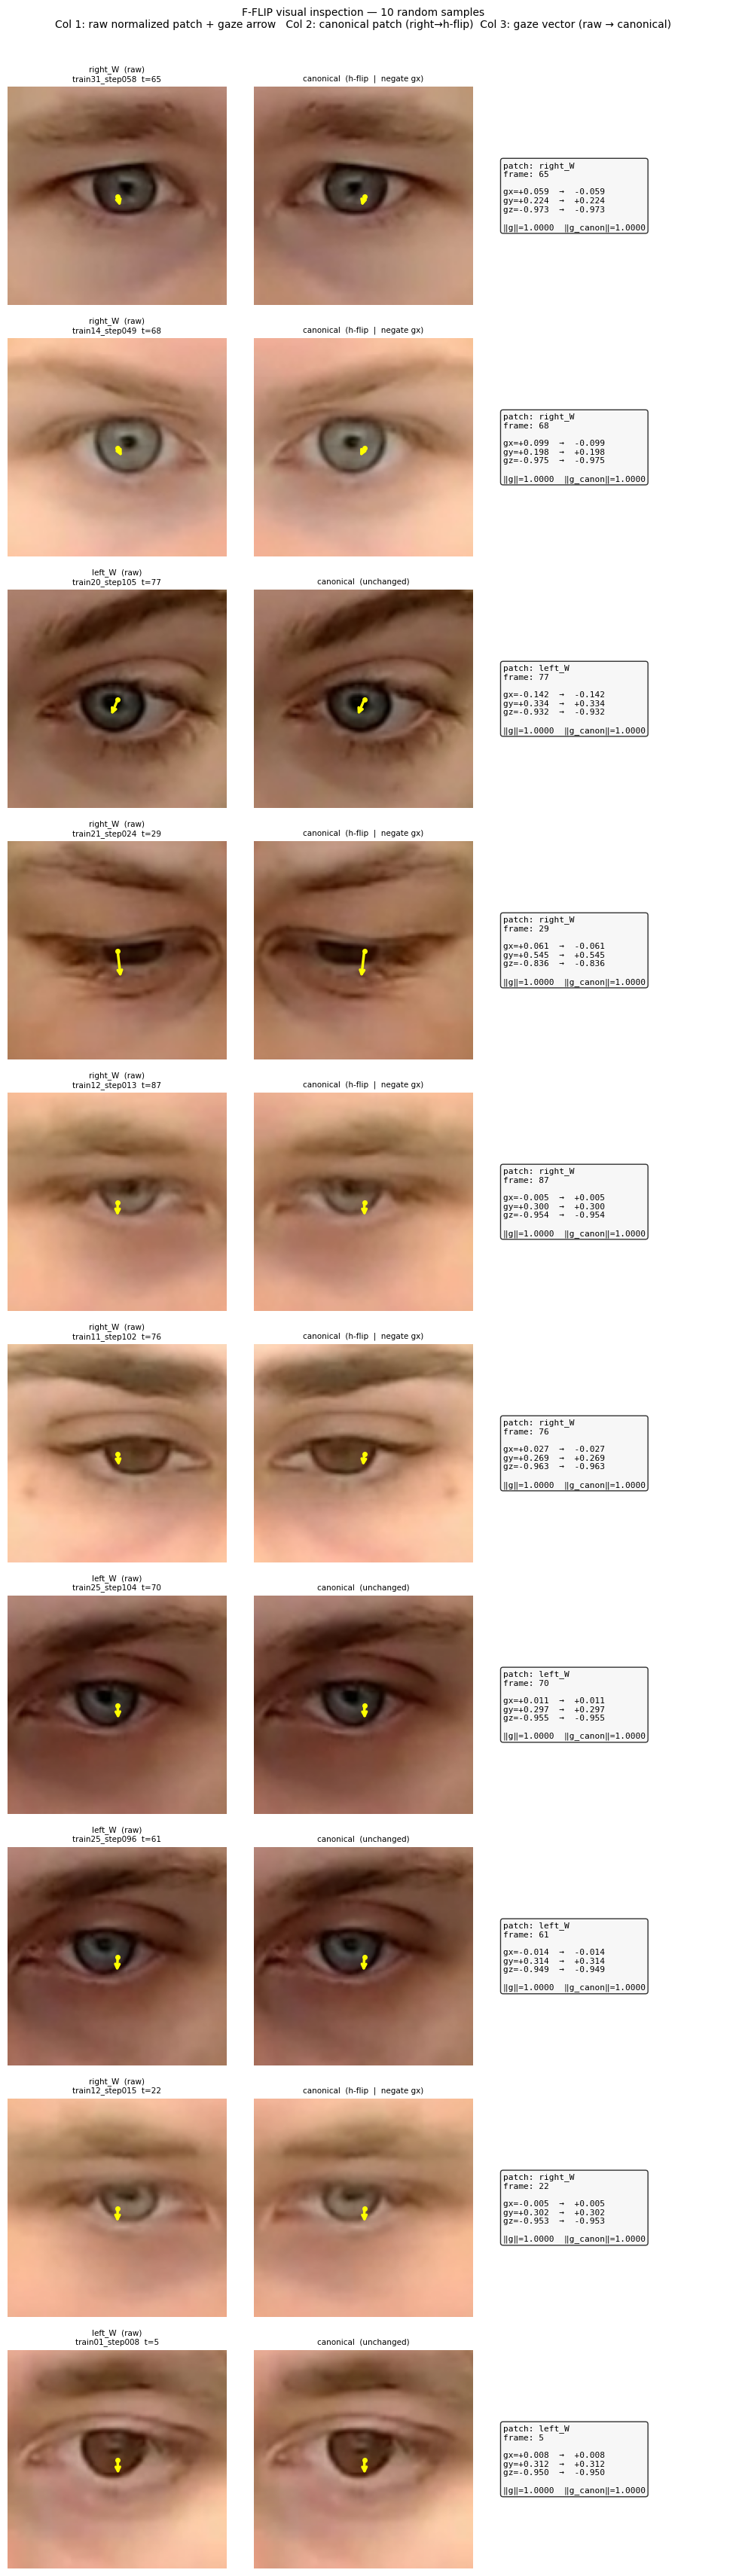

Saved to notebooks/inspect_f_flip_output.png


In [9]:
# ── render: for each sample show original | canonical (flipped if right) ─────
#
# Layout per row:
#   col 0: exp_key / frame / patch label
#   col 1: patch as produced by normalize_eye  (always left_W unmodified)
#   col 2: canonical patch  (right_W → h-flip; left_W → unchanged)
#   col 3: gaze vector before/after flip (printed as text cell)

N = len(samples)
fig, axes = plt.subplots(N, 3, figsize=(10, N * 3.4))

for row, (ek, t, patch) in enumerate(samples):
    img, g = get_patch_and_gaze(bundle, ek, t, patch, CROPS_ROOT)

    if patch == 'right':
        img_canon = flip_image(img)
        g_canon   = flip_gaze(g)
        action    = 'h-flip  |  negate gx'
    else:
        img_canon = img
        g_canon   = g
        action    = 'unchanged'

    ax_raw, ax_can, ax_txt = axes[row]

    # --- raw patch + raw gaze arrow ---
    ax_raw.imshow(img)
    draw_gaze_arrow(ax_raw, g)
    ax_raw.set_title(
        f'{patch}_W  (raw)\n{ek[:20]}  t={t}',
        fontsize=7.5,
    )
    ax_raw.axis('off')

    # --- canonical patch + canonical gaze arrow ---
    ax_can.imshow(img_canon)
    draw_gaze_arrow(ax_can, g_canon)
    ax_can.set_title(
        f'canonical  ({action})',
        fontsize=7.5,
    )
    ax_can.axis('off')

    # --- gaze vector text ---
    ax_txt.axis('off')
    gx_str   = f'gx={g[0]:+.3f}  →  {g_canon[0]:+.3f}'
    gy_str   = f'gy={g[1]:+.3f}  →  {g_canon[1]:+.3f}'
    gz_str   = f'gz={g[2]:+.3f}  →  {g_canon[2]:+.3f}'
    norm_str = f'‖g‖={np.linalg.norm(g):.4f}  ‖g_canon‖={np.linalg.norm(g_canon):.4f}'
    info = (
        f'patch: {patch}_W\n'
        f'frame: {t}\n\n'
        f'{gx_str}\n'
        f'{gy_str}\n'
        f'{gz_str}\n\n'
        f'{norm_str}'
    )
    ax_txt.text(
        0.05, 0.5, info,
        transform=ax_txt.transAxes,
        fontsize=8, va='center', family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8),
    )

plt.suptitle(
    'F-FLIP visual inspection — 10 random samples\n'
    'Col 1: raw normalized patch + gaze arrow   '
    'Col 2: canonical patch (right→h-flip)  '
    'Col 3: gaze vector (raw → canonical)',
    fontsize=10, y=1.005,
)
plt.tight_layout()
plt.savefig('../notebooks/inspect_f_flip_output.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved to notebooks/inspect_f_flip_output.png')

In [10]:
# ── sanity checks ─────────────────────────────────────────────────────────────
print('Flip sanity checks:')

all_ok = True
for i, (ek, t, patch) in enumerate(samples):
    img, g = get_patch_and_gaze(bundle, ek, t, patch, CROPS_ROOT)

    if patch == 'right':
        img_c = flip_image(img)
        g_c   = flip_gaze(g)
        # flip-then-flip == identity
        img_rr = flip_image(img_c)
        g_rr   = flip_gaze(g_c)
        img_id = np.array_equal(img_rr, img)
        g_id   = np.allclose(g_rr, g, atol=1e-10)
        unit   = abs(np.linalg.norm(g_c) - 1.0) < 1e-6
        ok = img_id and g_id and unit
        tag = 'OK' if ok else 'FAIL'
        if not ok:
            all_ok = False
        print(f'  {i+1:2d}. {patch}  flip-flip=id_img:{img_id}  flip-flip=id_vec:{g_id}  unit-norm:{unit}  → {tag}')
    else:
        unit = abs(np.linalg.norm(g) - 1.0) < 1e-6
        ok = unit
        if not ok:
            all_ok = False
        print(f'  {i+1:2d}. {patch}  unchanged  unit-norm:{unit}  → {"OK" if ok else "FAIL"}')

print()
print('All checks:', 'PASS' if all_ok else 'FAIL')

Flip sanity checks:
   1. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
   2. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
   3. left  unchanged  unit-norm:True  → OK
   4. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
   5. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
   6. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
   7. left  unchanged  unit-norm:True  → OK
   8. left  unchanged  unit-norm:True  → OK
   9. right  flip-flip=id_img:True  flip-flip=id_vec:True  unit-norm:True  → OK
  10. left  unchanged  unit-norm:True  → OK

All checks: PASS
